# Dataset Normalization
- Normalize each dataset to the range 0–1 based on metric direction

In [21]:
import os
import pandas as pd, numpy as np

ROOT_DIR = os.path.dirname(os.getcwd()) 

df = pd.read_csv(os.path.join(ROOT_DIR, "results", "admet_results.csv")) 

def larger_is_better(metric):
    metric = metric.upper()
    return not any(key in metric for key in ["MAE"])

def normalise(group):
    vals = group["mean"] # Mean values of the metric
    if larger_is_better(group.name[1]): # group.name = (data_name, metric)
        norm = (vals - vals.min()) / (vals.max() - vals.min())
    else:
        norm = (vals.max() - vals) / (vals.max() - vals.min())
    return norm

# add a new column with the normalised values
df["norm"] = (
    df.groupby(["data_name", "metric"], group_keys=False)
      .apply(normalise)
)

print(df.head())


   task_group data_name   metric   model   mean    std      norm
0  Absorption     Caco2      MAE  D-MPNN  0.377  0.030  0.779487
1  Absorption       HIA  ROC_AUC  D-MPNN  0.964  0.020  0.892157
2  Absorption       Pgp  ROC_AUC  D-MPNN  0.905  0.021  0.957265
3  Absorption     Bioav  ROC_AUC  D-MPNN  0.644  0.037  0.465116
4  Absorption      Lipo      MAE  D-MPNN  0.402  0.012  1.000000


# Heatmap

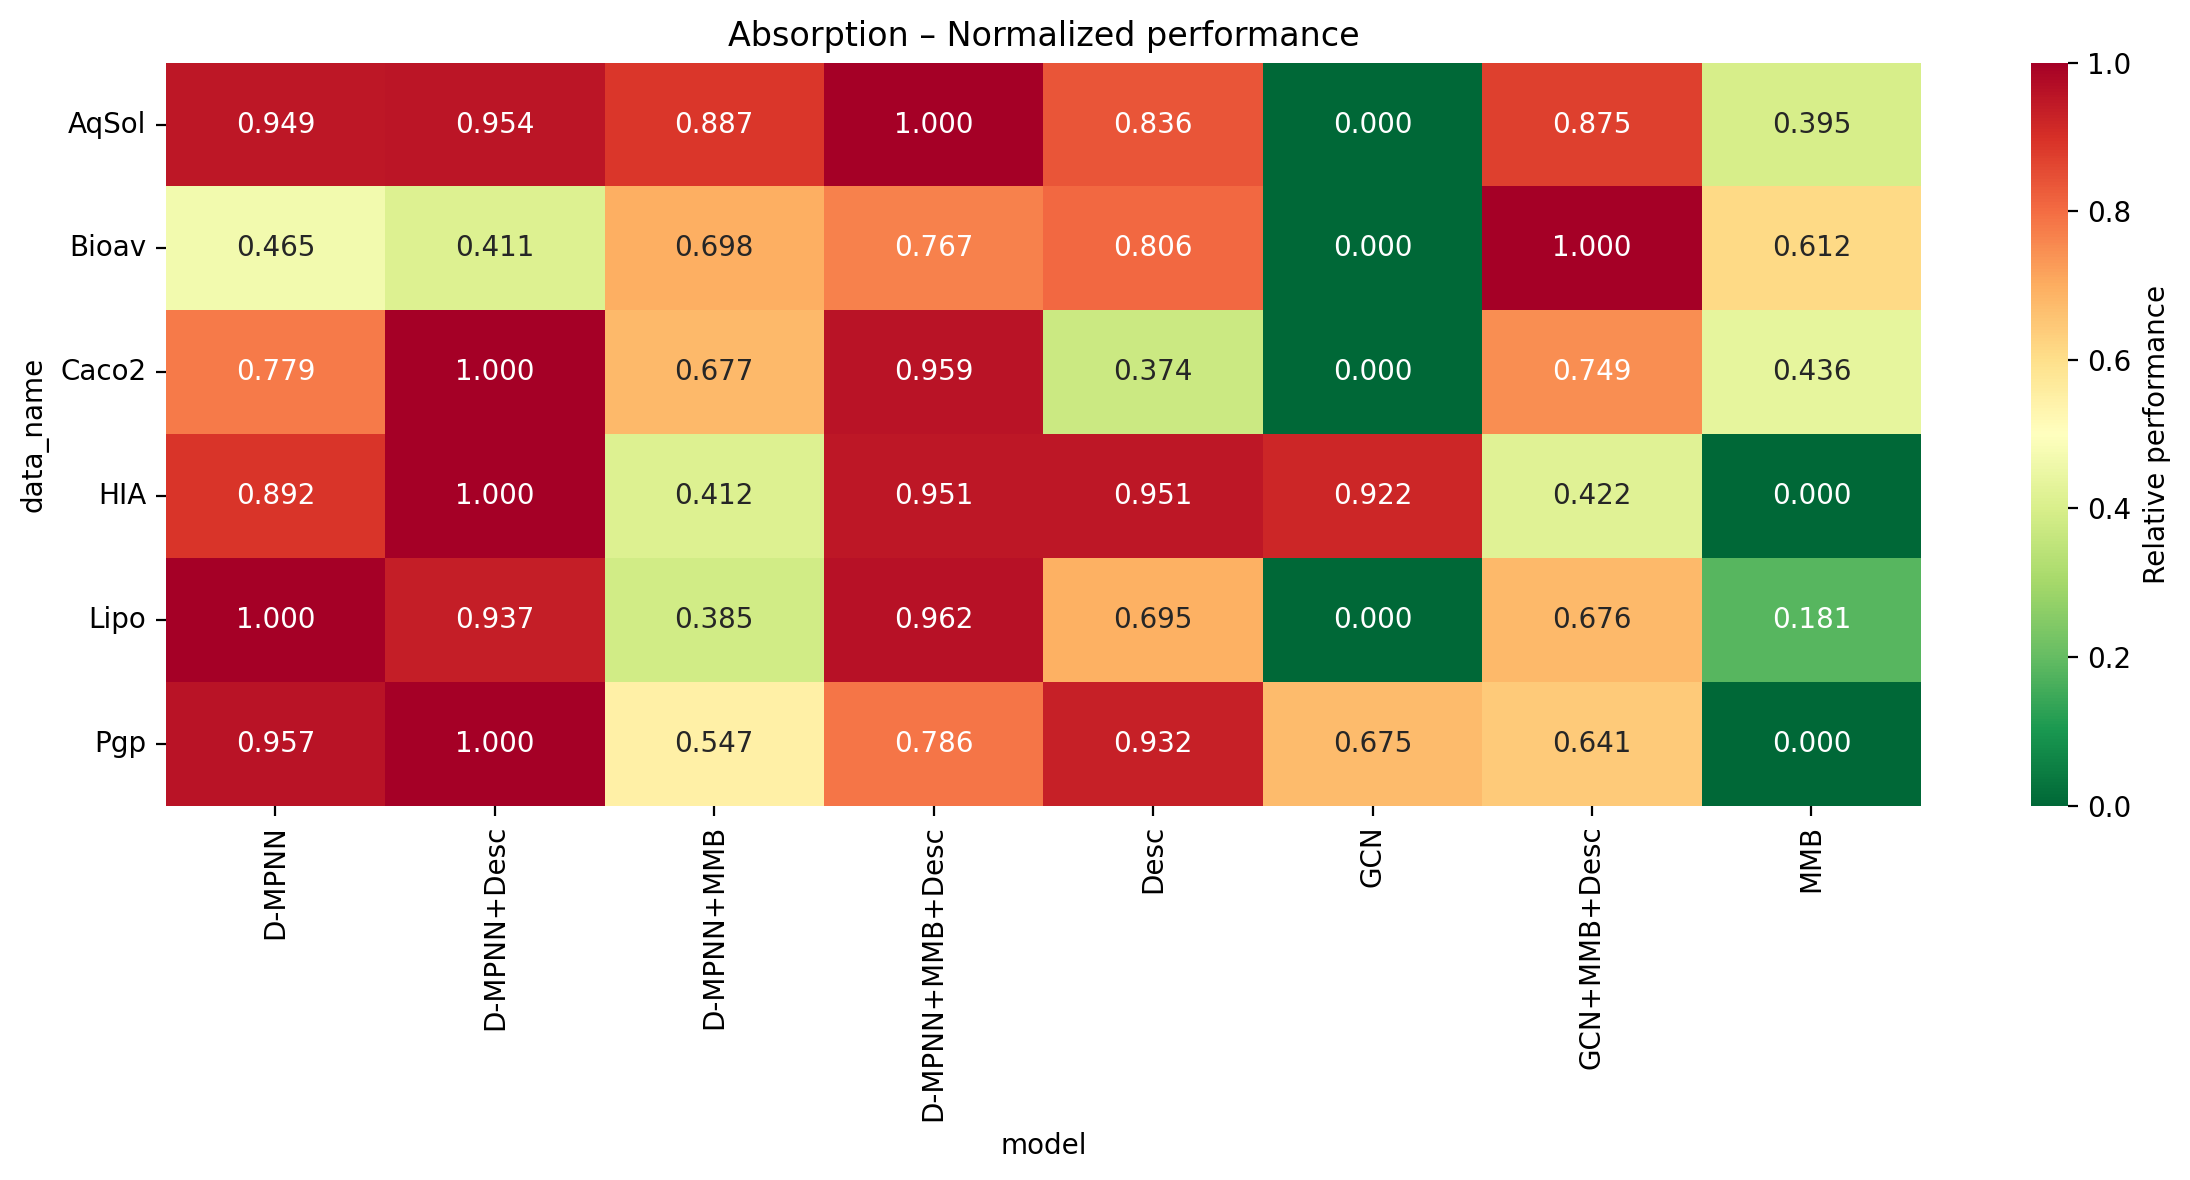

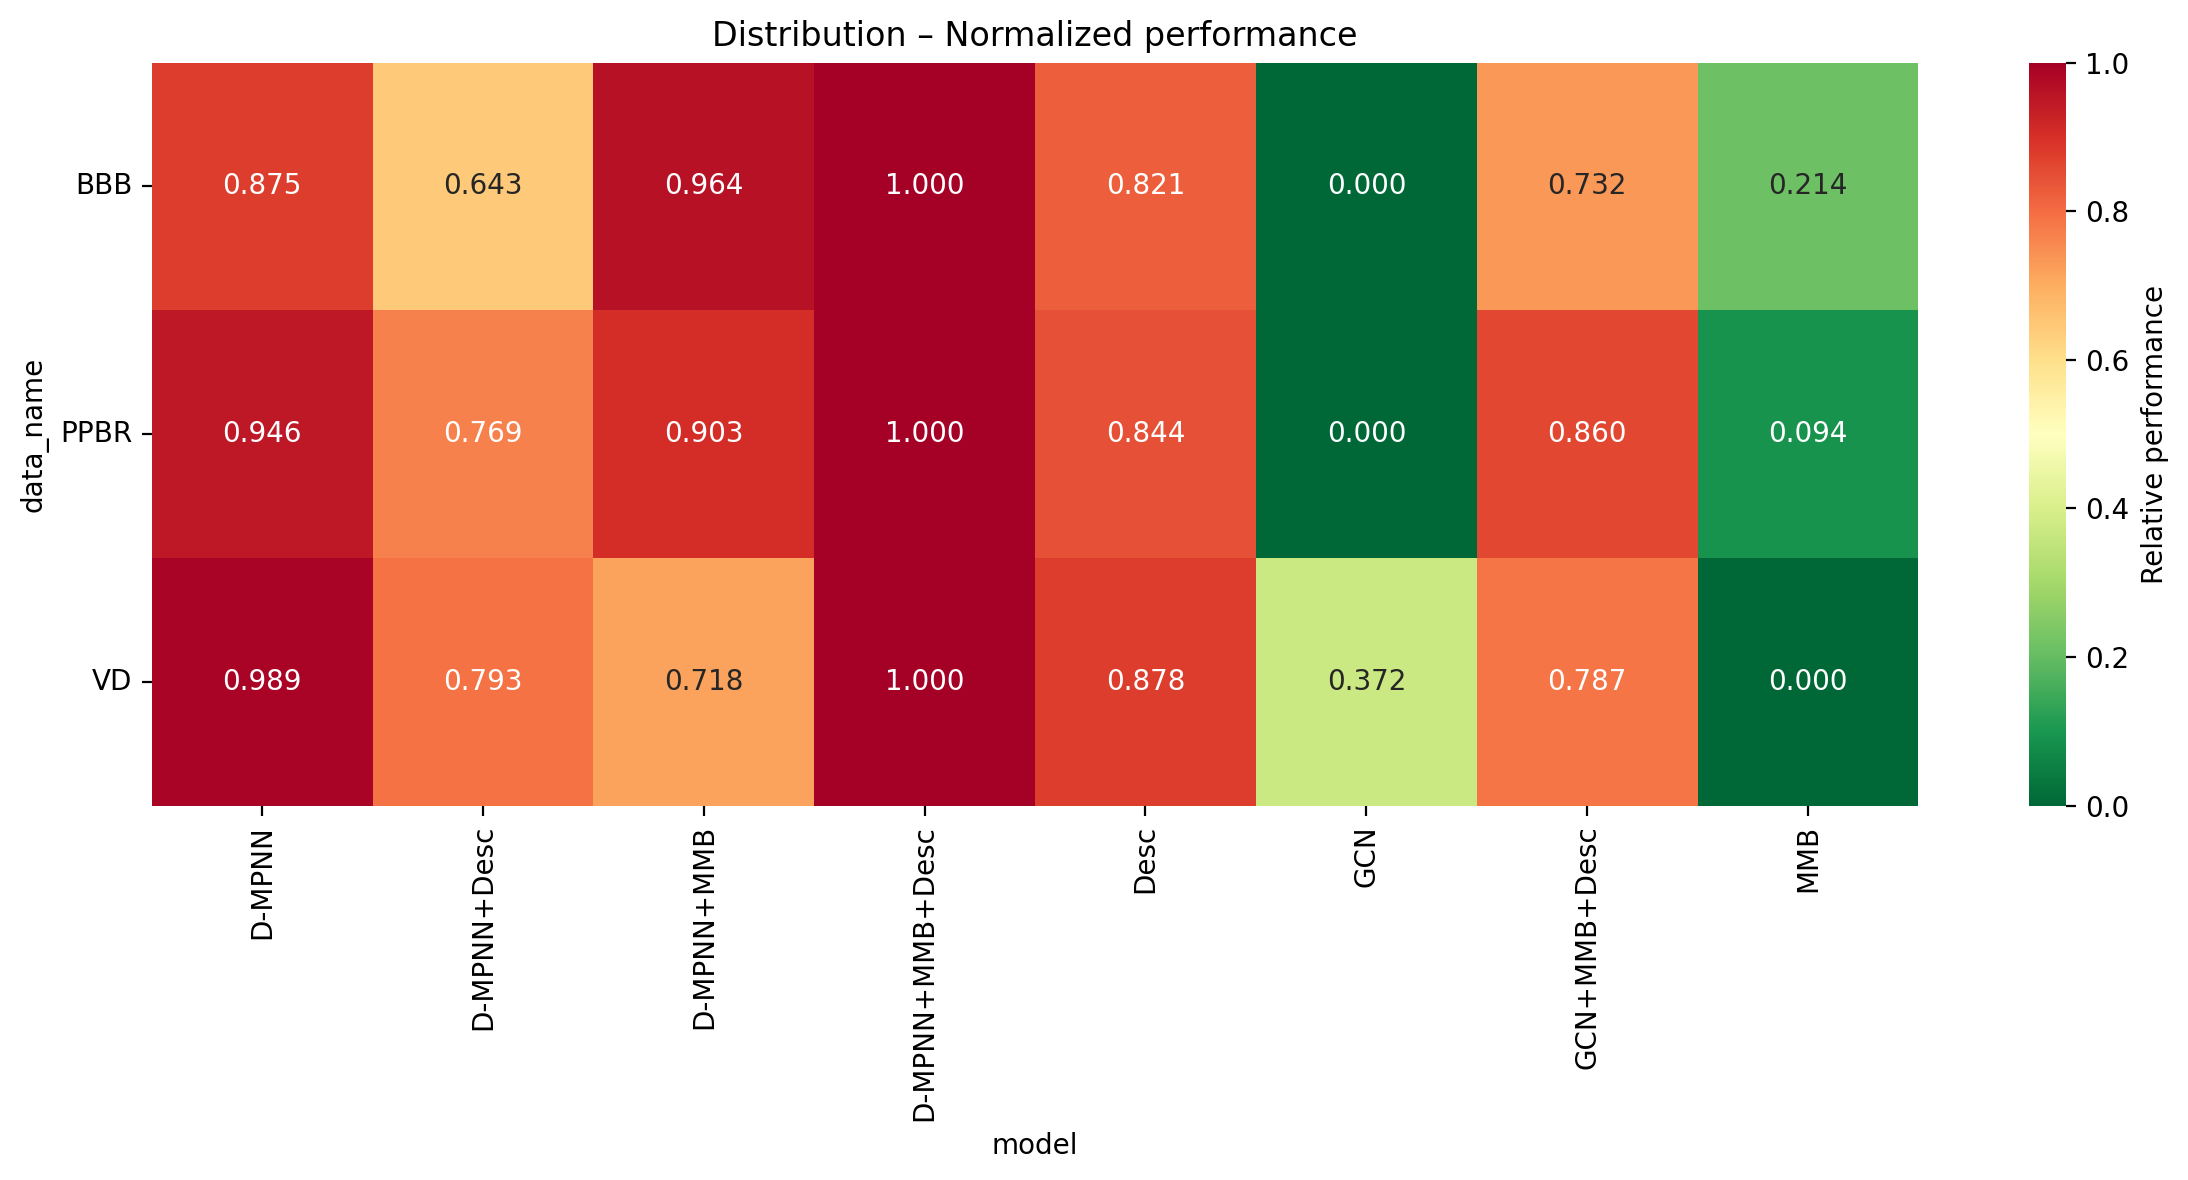

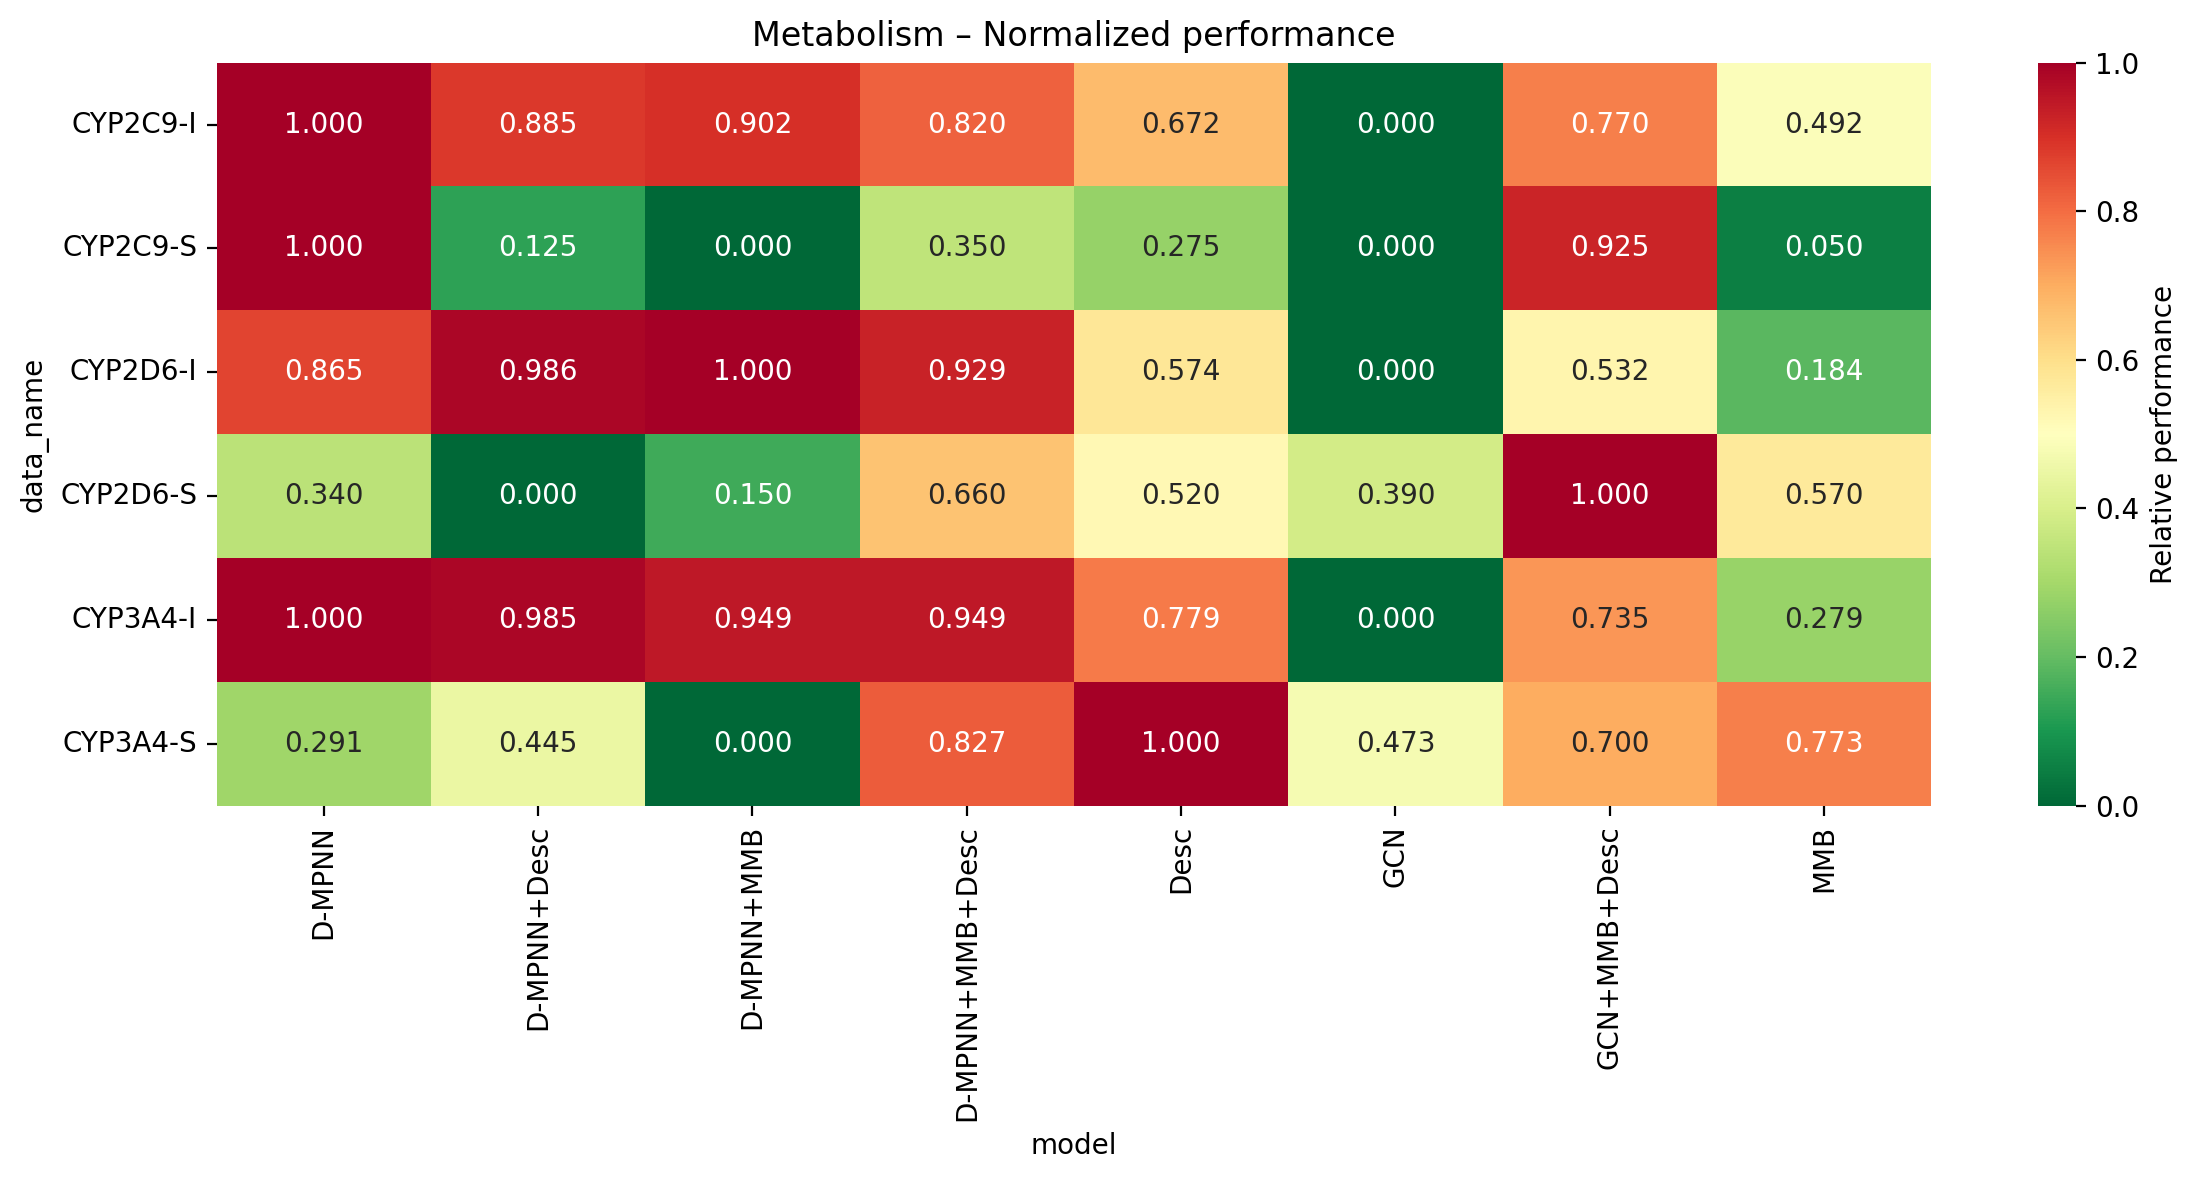

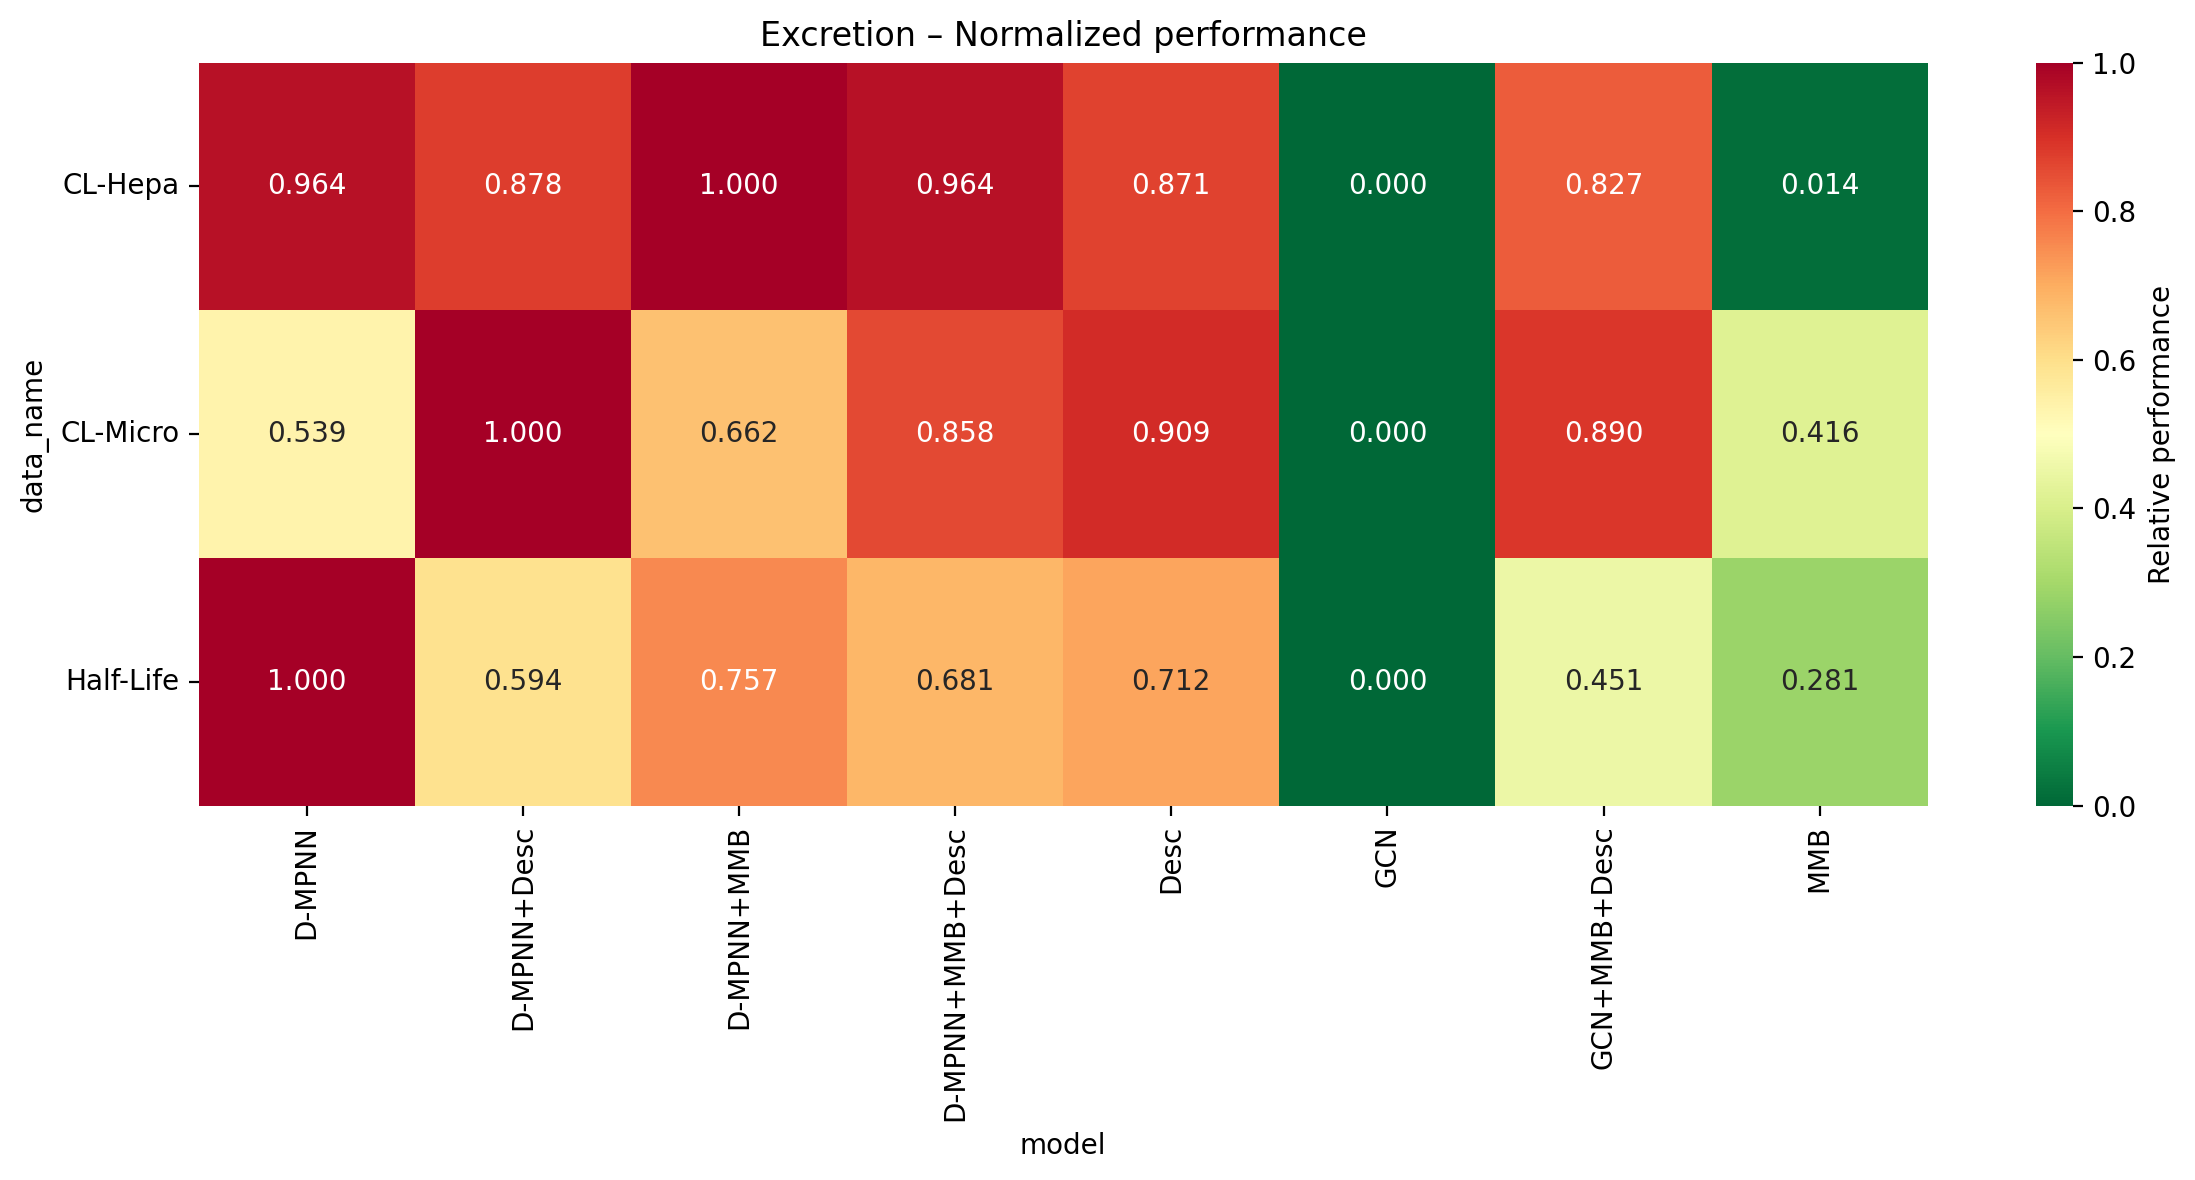

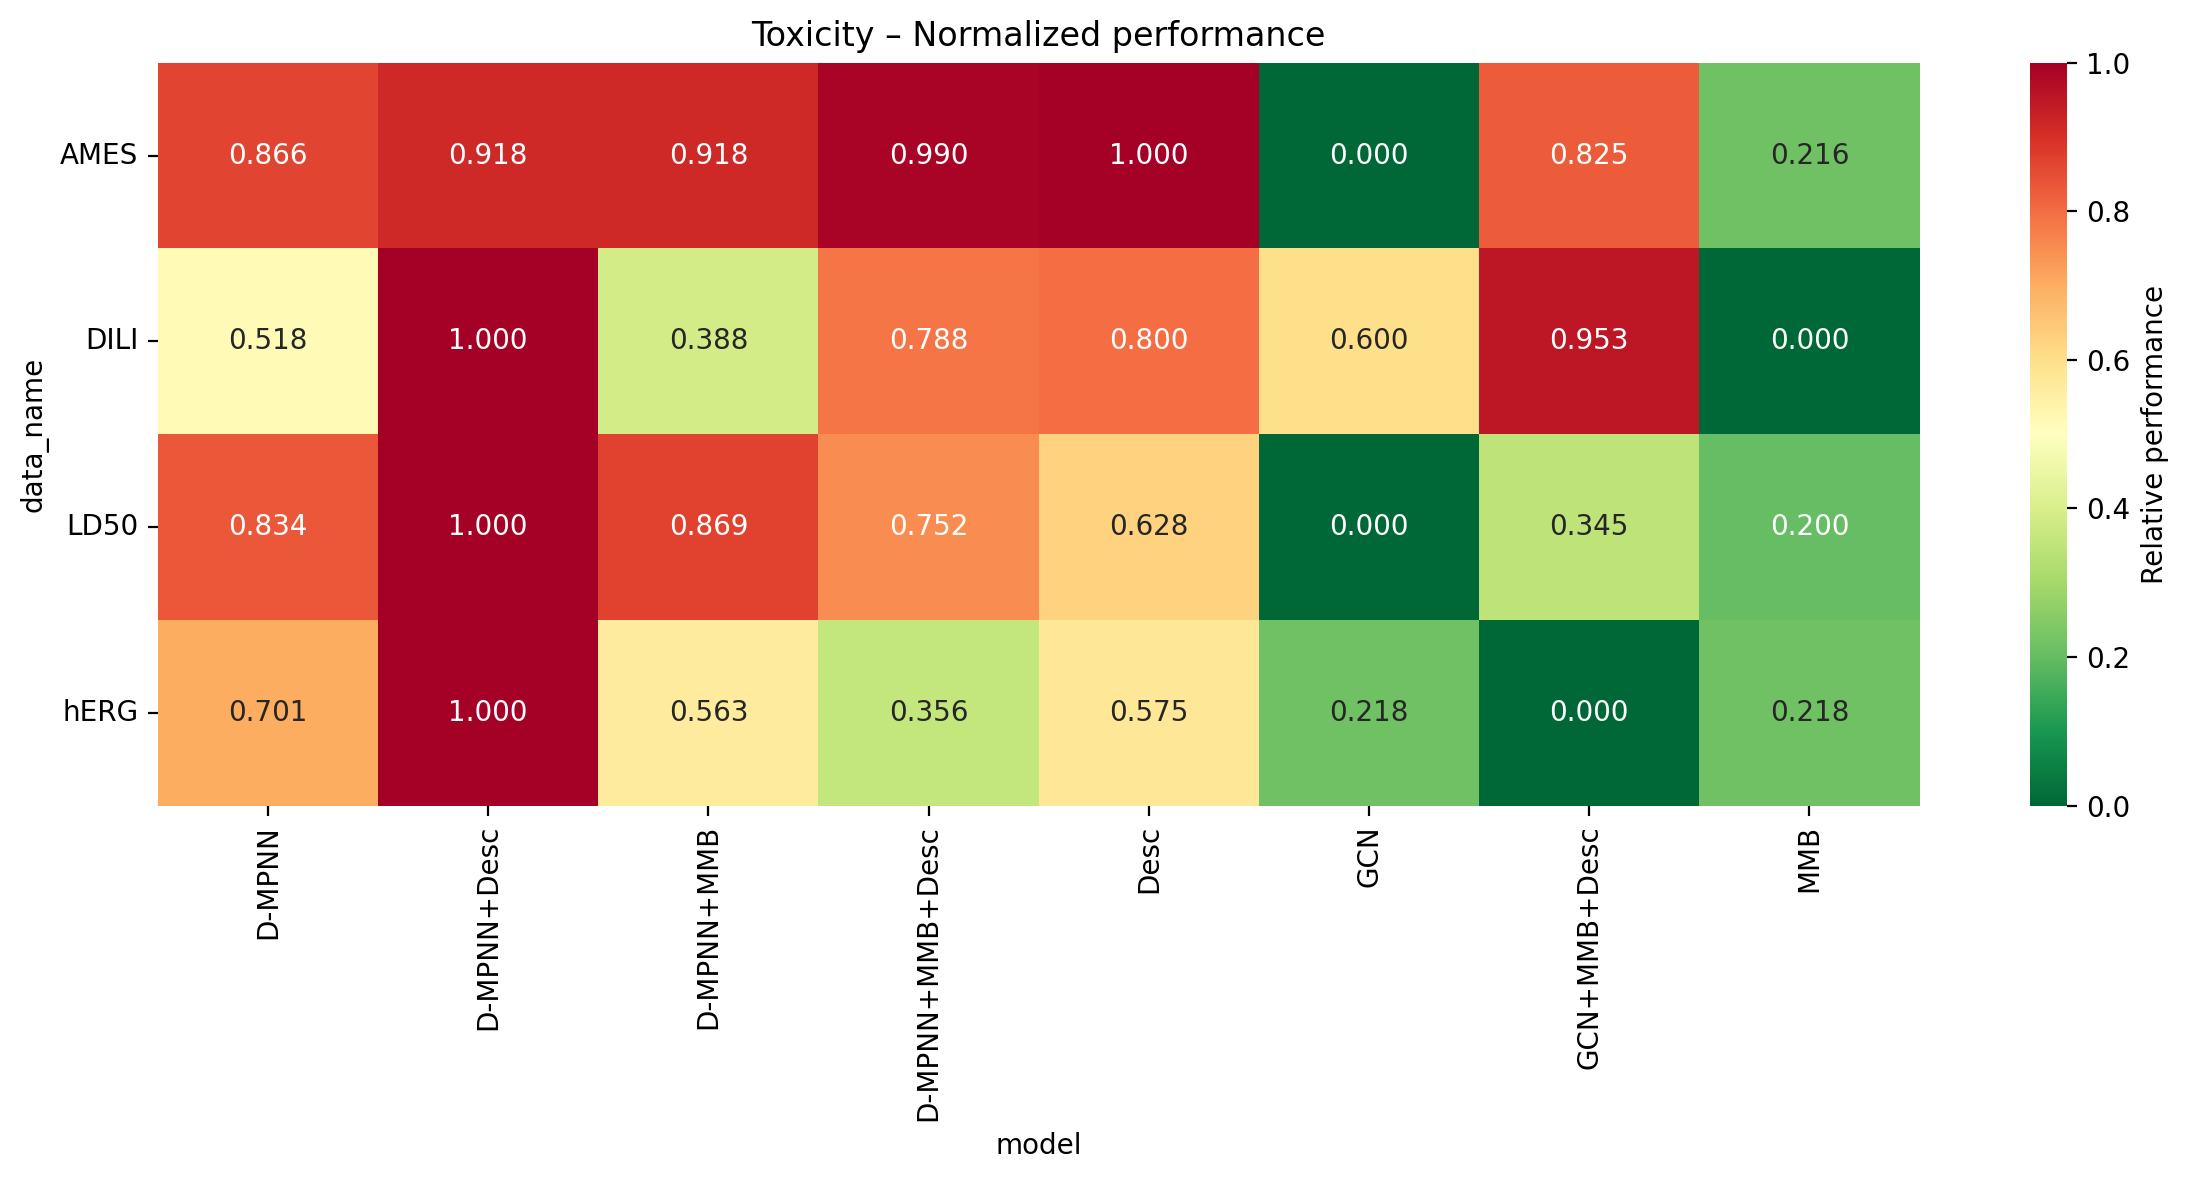

In [22]:
import seaborn as sns, matplotlib.pyplot as plt  
    
df["dataset_metric"] = df["data_name"] + "_" + df["metric"]

task_groups = df["task_group"].unique()
for tg in task_groups:
    heat_df = (
        df.query("task_group == @tg")
          # .pivot(index="dataset_metric", columns="model", values="norm")
          .pivot(index="data_name", columns="model", values="norm")
    )
    
    plt.figure(figsize=(12, 6), dpi=200)
    sns.heatmap(heat_df, cmap="RdYlGn_r", annot=True, fmt=".3f",
                vmin=0, vmax=1, cbar_kws={"label": "Relative performance"})
    plt.title(f"{tg} – Normalized performance")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


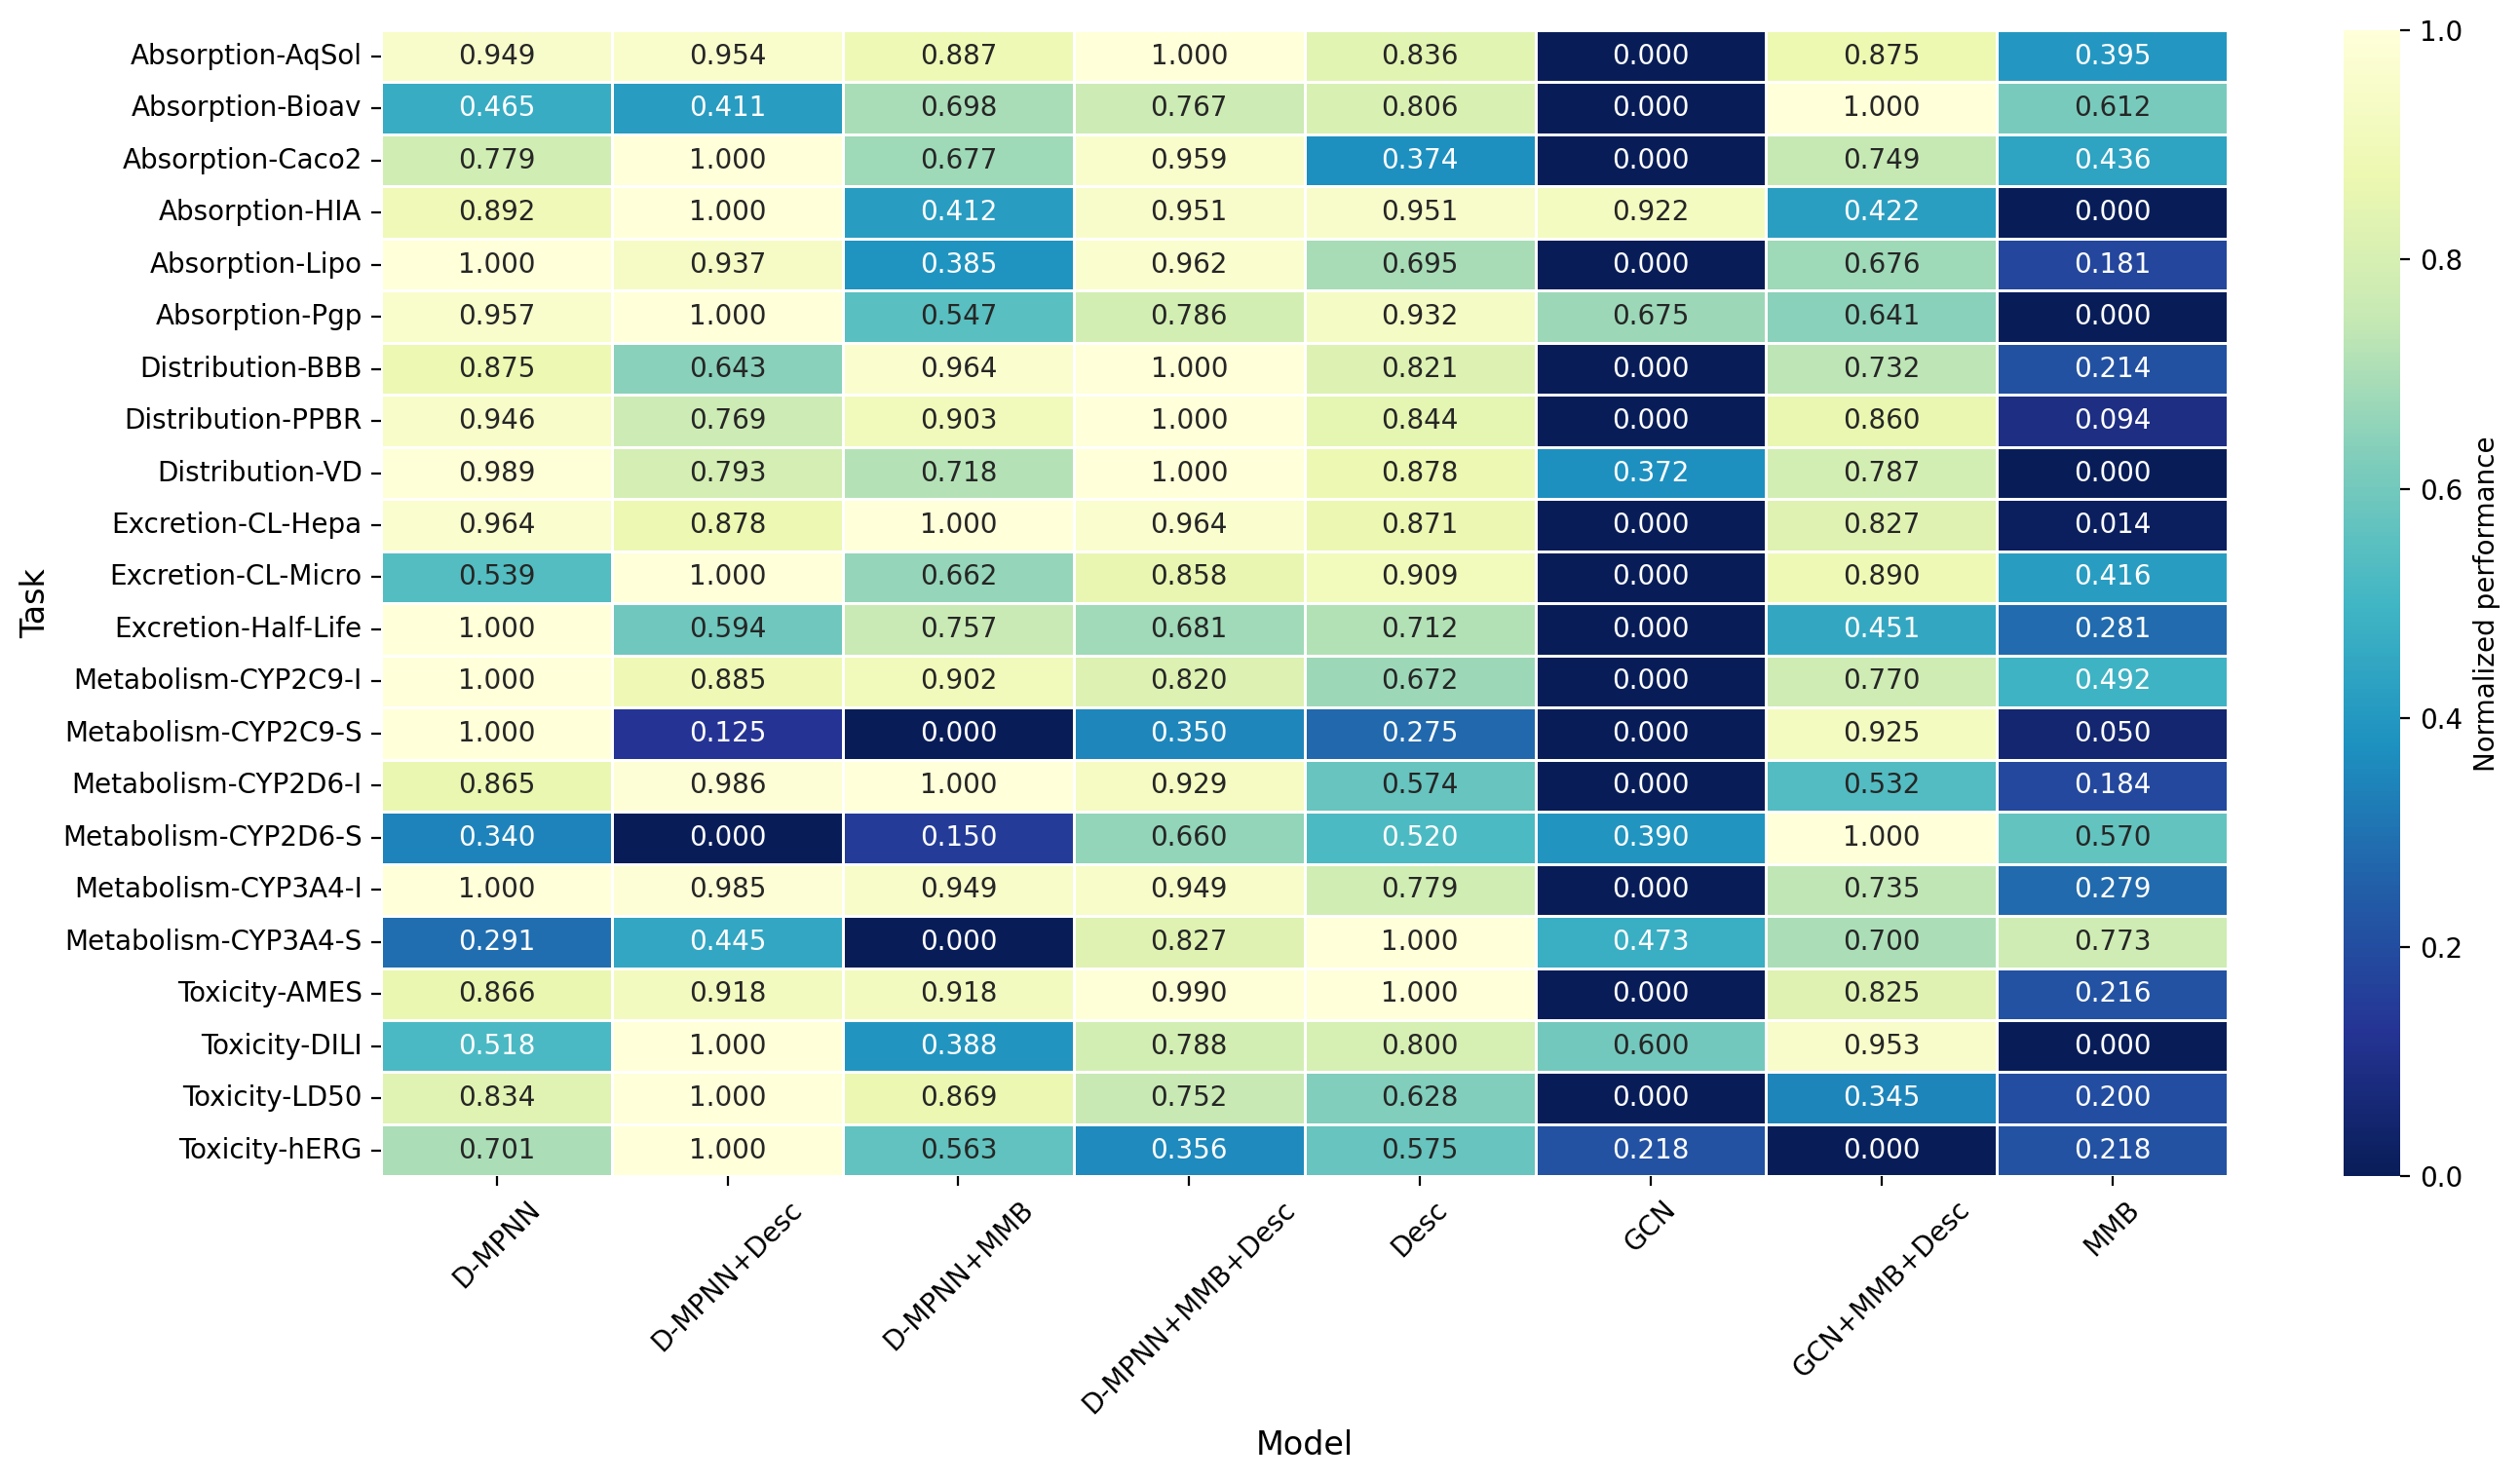

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 數值欄位：使用原本 normalized 數值
VALUE_COL = "norm"

# 🔹 模型顯示順序
model_order = [
    "D-MPNN", "D-MPNN+Desc", "D-MPNN+MMB", "D-MPNN+MMB+Desc", "Desc", "GCN", "GCN+MMB+Desc", "MMB"
]

# 🔹 依 task_group 與 dataset 排序
df_sorted = df.sort_values(["task_group", "data_name"])
pivot = (
    df_sorted
    .pivot_table(index=["task_group", "data_name"], columns="model", values=VALUE_COL)
    .reindex(columns=model_order)
)

# 🔹 畫圖設定
n_rows = pivot.shape[0]
fig_h = max(6, 0.35 * n_rows)
fig, ax = plt.subplots(figsize=(14, fig_h), dpi=200)

cmap = sns.color_palette("YlGnBu_r", as_cmap=True)

sns.heatmap(
    pivot,
    cmap=cmap,
    annot=True, fmt=".3f",
    vmin=0, vmax=1,
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Normalized performance"},
    ax=ax
)

# 🔸 X 軸放下方（預設）
ax.tick_params(axis="x", rotation=45, labelsize=10, bottom=True, top=False)
ax.tick_params(axis="y", rotation=0, labelsize=10)


# 🔸 移除 group 分隔線與 group label
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Task", fontsize=12)
# ax.set_title("All Task Groups – Normalized Performance", fontsize=14, pad=15)

plt.tight_layout()
plt.show()


# Radar chart

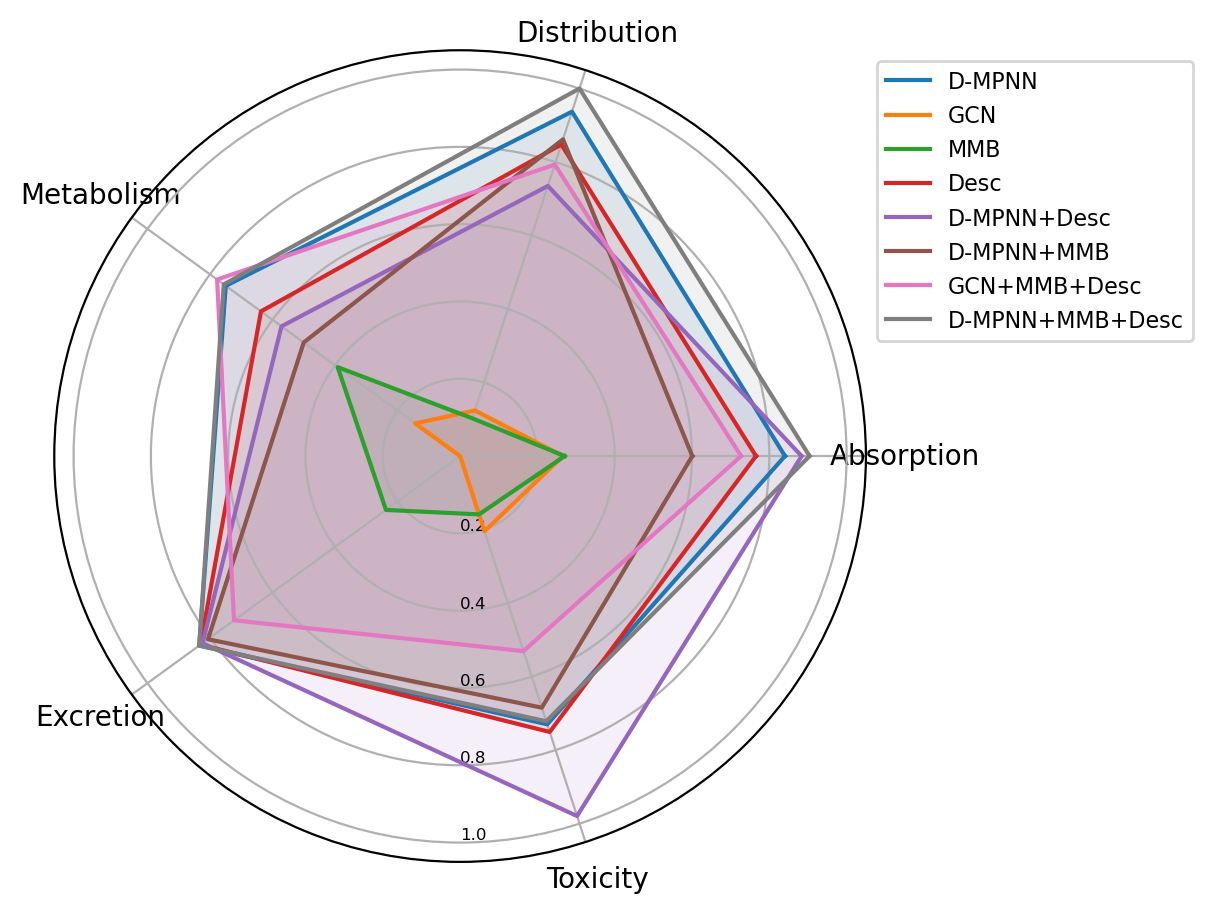

In [25]:
# --- Compute per‑task‑group average for selected models ------------------
# models_to_plot = ["D-MPNN", "MMB", "Desc", "D-MPNN+MMB+Desc"]
models_to_plot = ["D-MPNN", "GCN", "MMB", "Desc", "D-MPNN+Desc", "D-MPNN+MMB", "GCN+MMB+Desc", "D-MPNN+MMB+Desc"]
task_groups = ["Absorption", "Distribution", "Metabolism", "Excretion", "Toxicity"]

# exclude_tasks = ["AqSol_MAE", "CYP2C9-I_PR_AUC"]  # not needed
exclude_tasks = [] # not needed
filtered_df = df[~df["data_name"].isin(exclude_tasks)]

radar_df = (filtered_df[filtered_df["model"].isin(models_to_plot)]
              .groupby(["task_group", "model"])["norm"]
              .mean()
              .unstack())

# make sure the rows are ordered
radar_df = radar_df.reindex(task_groups)

# --- Radar plot ----------------------------------------------------------
labels = radar_df.index.tolist()
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # close the loop

plt.figure(figsize=(6, 6), dpi=200)
ax = plt.subplot(111, polar=True)

for model in models_to_plot:
    values = radar_df[model].tolist()
    values += values[:1]  # close loop
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
# ax.set_yticklabels([])
ax.set_rlabel_position(270) # adjust radial labels
ax.tick_params(axis='y', labelsize=6) # adjust radial label size
# plt.title("Average Normalized Performance per Task Group")
plt.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Comparison with SMILES-Mamba

In [26]:
import pandas as pd

df = pd.read_csv(os.path.join(ROOT_DIR, "results", "admet_results.csv")) 

mamba_rows = [
    # Absorption
    ("Absorption", "Caco2",     "MAE",      0.438, 0.030),
    ("Absorption", "HIA",       "ROC_AUC",  0.937, 0.011),
    ("Absorption", "Pgp",       "ROC_AUC",  0.930, 0.017),
    ("Absorption", "Bioav",     "ROC_AUC",  0.673, 0.025),
    ("Absorption", "Lipo",      "MAE",      0.583, 0.020),
    ("Absorption", "AqSol",     "MAE",      0.819, 0.020),

    # Distribution
    ("Distribution", "BBB",     "ROC_AUC",  0.852, 0.018),
    ("Distribution", "PPBR",    "MAE",      9.371, 0.311),
    ("Distribution", "VD",      "Spearman", 0.471, 0.099),

    # Metabolism
    ("Metabolism", "CYP2D6-I",  "PR_AUC",   0.747, 0.013),
    ("Metabolism", "CYP3A4-I",  "PR_AUC",   0.893, 0.012),
    ("Metabolism", "CYP2C9-I",  "PR_AUC",   0.845, 0.011),
    ("Metabolism", "CYP2D6-S",  "PR_AUC",   0.748, 0.012),
    ("Metabolism", "CYP3A4-S",  "ROC_AUC",  0.664, 0.027),
    ("Metabolism", "CYP2C9-S",  "PR_AUC",   0.365, 0.021),

    # Excretion
    ("Excretion", "Half-Life",  "Spearman", 0.247, 0.100),
    ("Excretion", "CL-Micro",   "Spearman", 0.501, 0.049),
    ("Excretion", "CL-Hepa",    "Spearman", 0.423, 0.029),

    # Toxicity
    ("Toxicity", "hERG",        "ROC_AUC",  0.708, 0.045),
    ("Toxicity", "AMES",        "ROC_AUC",  0.801, 0.030),
    ("Toxicity", "DILI",        "ROC_AUC",  0.928, 0.022),
    ("Toxicity", "LD50",        "MAE",      0.678, 0.012),
]

mamba_df = pd.DataFrame(mamba_rows, columns=["task_group","data_name","metric","mean","std"])
mamba_df["model"] = "SMILES-Mamba"

df_with_mamba = pd.concat([df, mamba_df], ignore_index=True)


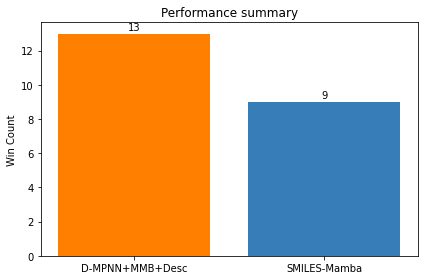

In [27]:
modelA = "D-MPNN+MMB+Desc"
modelB = "SMILES-Mamba"
wins = {modelA: 0, modelB: 0}

for _, group in df_with_mamba.groupby(["data_name", "metric"]):
    sub = group[group["model"].isin([modelA, modelB])]
    if len(sub) < 2: continue  # skip missing pairs
    vals = sub.set_index("model")["mean"]
    vA, vB = vals[modelA], vals[modelB]
    metric = sub["metric"].iloc[0]
    if larger_is_better(metric):
        better = modelA if vA > vB else modelB
    else:
        better = modelA if vA < vB else modelB
    wins[better] += 1

import matplotlib.pyplot as plt
plt.bar(wins.keys(), wins.values(), color=["#ff7f00","#377eb8"])
plt.ylabel("Win Count")
plt.title("Performance summary")
for i, (k, v) in enumerate(wins.items()):
    plt.text(i, v+0.2, str(v), ha='center')
plt.tight_layout(); plt.show()
